# Zepto Product Data Analysis

## 1. Import Libraries

In this project, we will use Python libraries to load, clean, analyze, and visualize the Zepto product dataset.

The main libraries used in this project are:

* **Pandas** — for loading and manipulating the dataset.
* **NumPy** — for numerical operations and data analysis.
* **Matplotlib** — for creating data visualizations.
* **Seaborn** — for creating statistical and analytical visualizations.

We begin by importing the libraries required for the analysis.


In [13]:
import pandas as pd

df = pd.read_csv("../data /sales_data.csv", encoding="cp1252")


## 3. Preview the Dataset

Before performing any analysis, we inspect the first few rows of the dataset.

This helps us understand the structure of the data, identify the available columns, and verify that the dataset has been loaded correctly.


In [15]:
df.head()


,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250


## 4. Check Dataset Dimensions

We check the number of rows and columns in the dataset.

The number of rows represents the number of product records, while the number of columns represents the variables available for analysis.


In [16]:
df.shape


(3732, 9)

## 5. Check Column Names

We examine the column names to understand the variables available in the dataset.

Knowing the column names is important because they will be used throughout the data cleaning, analysis, and visualization stages.


In [17]:
df.columns

Index(['Category', 'name', 'mrp', 'discountPercent', 'availableQuantity',
       'discountedSellingPrice', 'weightInGms', 'outOfStock', 'quantity'],
      dtype='str')

## 6. Understand the Dataset Structure

The `info()` method provides an overview of the dataset, including:

* Number of records
* Column names
* Data types
* Number of non-null values
* Memory usage

This helps us identify potential data-quality issues before beginning the cleaning process.


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3732 entries, 0 to 3731
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Category                3732 non-null   str  
 1   name                    3732 non-null   str  
 2   mrp                     3732 non-null   int64
 3   discountPercent         3732 non-null   int64
 4   availableQuantity       3732 non-null   int64
 5   discountedSellingPrice  3732 non-null   int64
 6   weightInGms             3732 non-null   int64
 7   outOfStock              3732 non-null   bool 
 8   quantity                3732 non-null   int64
dtypes: bool(1), int64(6), str(2)
memory usage: 237.0 KB


In [20]:
df.isnull().sum()

Category                  0
name                      0
mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
outOfStock                0
quantity                  0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(2)

In [22]:
df[df.duplicated()]

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
2946,Personal Care,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250
3290,Paan Corner,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250


In [23]:
df[df.duplicated(keep=False)].sort_values("name")

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
2908,Personal Care,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250
2946,Personal Care,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250
3252,Paan Corner,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250
3290,Paan Corner,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250


## 9. Remove Exact Duplicate Records

The inspection showed that some rows were exact duplicates within the dataset.

Since these records contain identical information, we remove the duplicate rows to prevent them from affecting our analysis.

The cleaned DataFrame will retain only unique records.


In [24]:
df = df.drop_duplicates()

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.describe()

,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,quantity
count,3730.000000,3730.000000,3730.000000,3730.000000,3730.000000,3730.000000
mean,15680.482574,7.615818,4.007507,14193.206434,387.917694,213.251206
std,16093.113838,9.214038,2.203619,13854.430798,678.270812,194.781332
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6000.000000,0.000000,2.000000,5500.000000,100.000000,50.000000
50%,11000.000000,6.000000,5.000000,10400.000000,225.000000,181.000000
75%,20000.000000,10.000000,6.000000,18400.000000,450.000000,340.000000
max,260000.000000,51.000000,6.000000,139900.000000,10000.000000,1500.000000


In [27]:
df[df["mrp"] == 0]

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
3606,Home & Cleaning,Cherry Blossom Liquid Shoe Polish Neutral,0,0,1,0,75,False,75


In [28]:
(df["mrp"] == 0).sum()

np.int64(1)

In [29]:
 df[df["discountedSellingPrice"] == 0]

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
3606,Home & Cleaning,Cherry Blossom Liquid Shoe Polish Neutral,0,0,1,0,75,False,75


In [30]:
(df["discountedSellingPrice"] == 0).sum()

np.int64(1)

In [31]:
df_clean = df[df["mrp"] > 0].copy()

In [32]:
df_clean.shape

(3729, 9)

In [33]:
df_clean["mrp"].min()

np.int64(1000)

## 10. Pricing Validation

Pricing is one of the key variables in this product dataset.

We will validate whether the `discountedSellingPrice` is consistent with the product's `mrp` and `discountPercent`.

The expected discounted price can be calculated using:

**Discounted Price = MRP × (1 − Discount Percentage / 100)**

This validation helps identify records where the stored selling price may not match the given MRP and discount percentage.


In [34]:
df_clean["calculatedSellingPrice"] = (
    df_clean["mrp"] *
    (1 - df_clean["discountPercent"] / 100)
).round(2)

## 11. Compare Actual and Calculated Prices

We now compare the original `discountedSellingPrice` with the price calculated from the MRP and discount percentage.

This allows us to determine whether the pricing information in the dataset is internally consistent.


In [35]:
df_clean[
    [
        "mrp",
        "discountPercent",
        "discountedSellingPrice",
        "calculatedSellingPrice"
    ]
].head(10)

,mrp,discountPercent,discountedSellingPrice,calculatedSellingPrice
0,2500,16,2100,2100.0
1,4200,16,3500,3528.0
2,5100,15,4300,4335.0
3,2000,15,1700,1700.0
4,1400,14,1200,1204.0
5,3500,17,2900,2905.0
6,7500,16,6300,6300.0
7,5800,15,4900,4930.0
8,2300,17,1900,1909.0
9,1900,15,1600,1615.0


## 13. Analyze Price Differences

We examine the statistical distribution of the price differences to understand how closely the recorded selling prices match the calculated prices.

This helps us determine whether the differences are small and likely related to rounding or whether further investigation is required.
|

In [39]:
df_clean["price_difference"] = (
    df_clean["discountedSellingPrice"]
    - df_clean["calculatedSellingPrice"]
).round(2)


In [40]:
df_clean["price_difference"].describe()


count    3729.000000
mean      -39.805578
std        79.233205
min      -822.000000
25%       -50.000000
50%        -2.000000
75%         0.000000
max         0.000000
Name: price_difference, dtype: float64

## 14. Investigate Pricing Differences

The pricing validation shows that the recorded discounted selling prices are generally slightly lower than the mathematically calculated prices.

This can occur because e-commerce platforms may apply their own pricing and rounding rules.

We will inspect the products with the largest differences to understand the pattern before deciding whether any further cleaning is required.


In [41]:
df_clean[
    [
        "name",
        "mrp",
        "discountPercent",
        "discountedSellingPrice",
        "calculatedSellingPrice",
        "price_difference"
    ]
].sort_values("price_difference").head(10)

,name,mrp,discountPercent,discountedSellingPrice,calculatedSellingPrice,price_difference
3367,Pampers Active Baby Diapers New Born Extra Small,109900,22,84900,85722.0,-822.0
3023,Pampers Active Baby Diapers New Born Extra Small,109900,22,84900,85722.0,-822.0
635,Dhara Kachi Ghani Mustard Oil Jar,125000,8,114300,115000.0,-700.0
121,Dhara Kachi Ghani Mustard Oil Jar,125000,8,114300,115000.0,-700.0
3556,Surf Excel Matic Top Load,72000,9,64900,65520.0,-620.0
3037,Gillette Mach 3 Turbo Cartridges,64900,10,57800,58410.0,-610.0
3381,Gillette Mach 3 Turbo Cartridges,64900,10,57800,58410.0,-610.0
114,Fortune Soyabean Oil,100500,0,99900,100500.0,-600.0
628,Fortune Soyabean Oil,100500,0,99900,100500.0,-600.0
2481,Pedigree Dog Food Adult Meat & Rice,66000,7,60800,61380.0,-580.0


## 15. Check for Missing Values

Missing values can affect calculations, visualizations, and statistical analysis.

We will check every column in the cleaned dataset to determine whether any product records contain missing information.

This will help us decide whether missing values need to be removed, replaced, or investigated further.


In [42]:
df_clean.isnull().sum()

Category                  0
name                      0
mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
outOfStock                0
quantity                  0
calculatedSellingPrice    0
price_difference          0
dtype: int64

## 16. Calculate Missing Value Percentage

The number of missing values alone does not tell us how significant the problem is.

We calculate the percentage of missing values in each column relative to the total number of records.

This helps us understand the overall data quality and determine whether missing values could significantly affect our analysis.


In [43]:
missing_percentage = (
    df_clean.isnull().sum() / len(df_clean) * 100
)

missing_percentage.sort_values(ascending=False)

Category                  0.0
name                      0.0
mrp                       0.0
discountPercent           0.0
availableQuantity         0.0
discountedSellingPrice    0.0
weightInGms               0.0
outOfStock                0.0
quantity                  0.0
calculatedSellingPrice    0.0
price_difference          0.0
dtype: float64

## 17. Check Data Types

Different types of analysis require appropriate data types.

For example:

* Prices should be numerical.
* Discount percentages should be numerical.
* Product names and categories should be text.
* Stock availability should be represented as a Boolean value.

We inspect the current data types to identify any columns that may require conversion or further cleaning.


In [44]:
df_clean.dtypes


Category                      str
name                          str
mrp                         int64
discountPercent             int64
availableQuantity           int64
discountedSellingPrice      int64
weightInGms                 int64
outOfStock                   bool
quantity                    int64
calculatedSellingPrice    float64
price_difference          float64
dtype: object

## 18. Explore Product Categories

Product categories help us understand how the product catalog is distributed across different types of products.

We will first identify the number of unique categories and then examine how many products belong to each category.

This can help us understand which product categories have the largest representation in the dataset.


In [45]:
df_clean["Category"].nunique()

14

## 19. Count Products by Category

We now calculate the number of products available in each category.

This allows us to compare the size of different product categories within the catalog.


In [46]:
category_counts = (
    df_clean["Category"]
    .value_counts()
)

category_counts

Category
Cooking Essentials       514
Munchies                 514
Packaged Food            388
Ice Cream & Desserts     388
Chocolates & Candies     388
Personal Care            343
Paan Corner              343
Home & Cleaning          193
Biscuits                 147
Dairy, Bread & Batter    129
Beverages                129
Health & Hygiene          97
Fruits & Vegetables       93
Meats, Fish & Eggs        63
Name: count, dtype: int64

## 20. Identify the Largest Product Categories

To make the category distribution easier to analyze, we will identify the categories containing the highest number of products.

This can help highlight the areas where the product catalog has the greatest variety.


In [47]:
category_counts.head(10)

Category
Cooking Essentials       514
Munchies                 514
Packaged Food            388
Ice Cream & Desserts     388
Chocolates & Candies     388
Personal Care            343
Paan Corner              343
Home & Cleaning          193
Biscuits                 147
Dairy, Bread & Batter    129
Name: count, dtype: int64

## 21. Visualize Product Categories

A visualization makes it easier to compare the number of products across categories.

We will create a bar chart showing the 10 categories with the highest number of products.


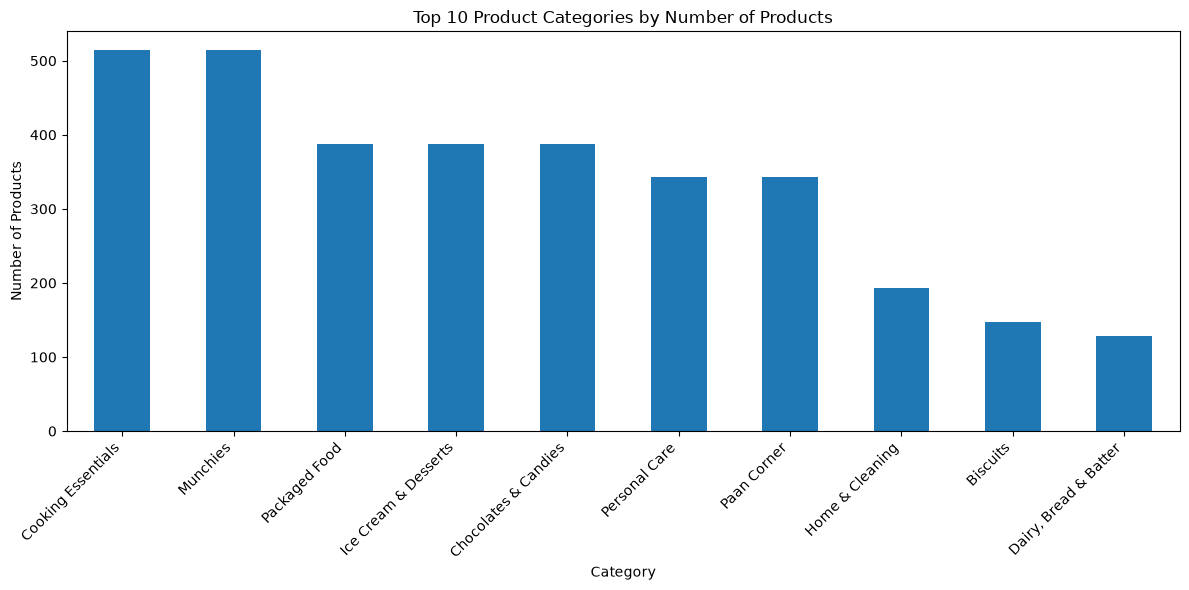

In [48]:
plt.figure(figsize=(12, 6))

category_counts.head(10).plot(kind="bar")

plt.title("Top 10 Product Categories by Number of Products")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## 22. Analyze MRP Distribution

The MRP variable represents the listed price of a product.

We will examine its statistical distribution to understand the range of product prices and identify potentially unusual values.

Understanding the distribution of prices will help us perform further pricing analysis.


In [49]:
df_clean["mrp"].describe()

count      3729.000000
mean      15684.687584
std       16093.222553
min        1000.000000
25%        6000.000000
50%       11000.000000
75%       20000.000000
max      260000.000000
Name: mrp, dtype: float64

## 23. Visualize MRP Distribution

Summary statistics provide numerical information about product prices, but a visualization can help us understand the overall shape of the price distribution.

We will use a histogram to see how product MRP values are distributed across different price ranges.


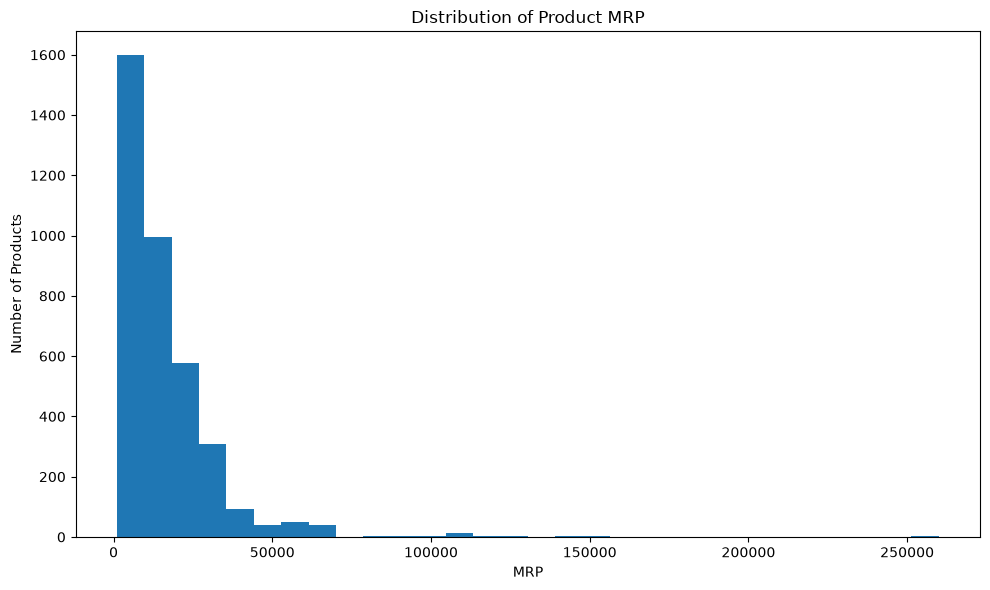

In [50]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["mrp"], bins=30)

plt.title("Distribution of Product MRP")
plt.xlabel("MRP")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

## 24. Analyze Discount Distribution

Discount percentage is an important variable for understanding the pricing structure of the product catalog.

We will examine the statistical distribution of discounts to understand the typical discount levels and their overall range.


In [51]:


df_clean["discountPercent"].describe()

count    3729.000000
mean        7.617860
std         9.214429
min         0.000000
25%         0.000000
50%         6.000000
75%        10.000000
max        51.000000
Name: discountPercent, dtype: float64

In [52]:
discount_counts = (
    df_clean["discountPercent"]
    .value_counts()
    .sort_index()
)

discount_counts

discountPercent
0     1177
1       44
2      186
3       86
4      122
5      226
6      213
7      127
8       69
9      201
10     466
11      69
12      43
13      39
14      61
15     125
16      58
17      49
18      21
19       1
20     113
21       7
22      13
23       1
24       6
25      28
26      15
27       5
28       8
29       7
30      56
31       2
32       2
33       2
35       2
40      10
43       4
45       2
46       2
49       3
50      55
51       3
Name: count, dtype: int64

## 26. Visualize Discount Distribution

We will create a bar chart showing the number of products associated with each discount percentage.

This visualization allows us to easily identify the most common discount levels in the product catalog.



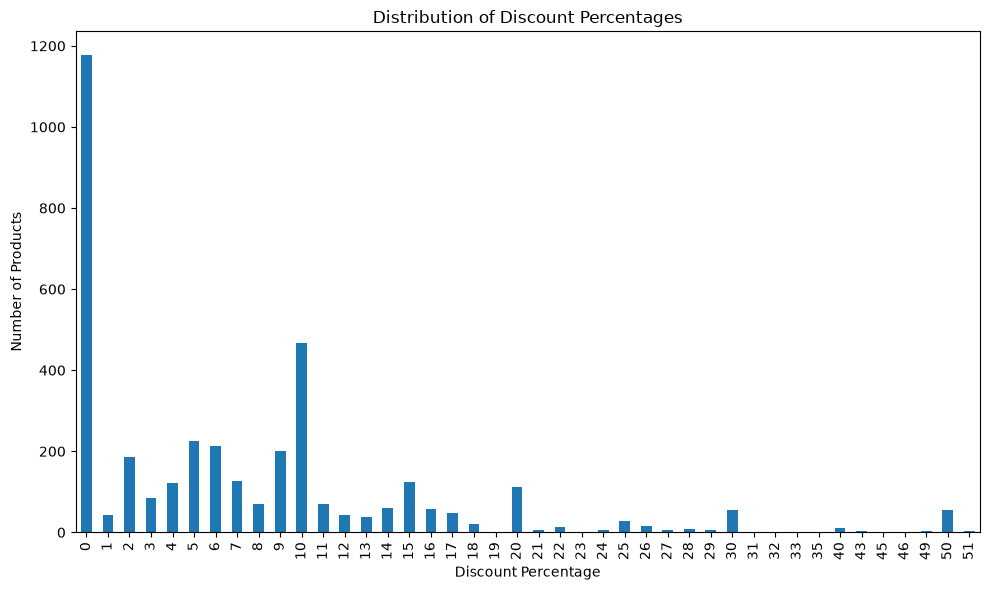

In [54]:
plt.figure(figsize=(10, 6))

discount_counts.plot(kind="bar")

plt.title("Distribution of Discount Percentages")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

## 27. Average Discount by Product Category

In this step, we calculate the average discount percentage for each product category.

This helps us compare discounting patterns across different categories and identify categories where products are generally offered with higher or lower discounts.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("../data /sales_data.csv", encoding="cp1252")

In [9]:
df.head()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250


In [10]:
df_clean = df.drop_duplicates().copy()

In [11]:
df_clean.shape

(3730, 9)

In [13]:
category_discount = (
    df_clean.groupby("Category")["discountPercent"]
    .mean()
    .sort_values(ascending=False)
)

category_discount.head(10)

Category
Fruits & Vegetables     15.462366
Meats, Fish & Eggs      11.031746
Chocolates & Candies     8.324742
Ice Cream & Desserts     8.324742
Packaged Food            8.324742
Biscuits                 8.244898
Health & Hygiene         8.051546
Cooking Essentials       7.163424
Munchies                 7.163424
Beverages                7.155039
Name: discountPercent, dtype: float64

## 28. Visualize Average Discount by Category

In this step, we visualize the average discount percentage for each product category.

The bar chart helps us compare discounting patterns across categories and identify categories with relatively higher or lower average discounts.

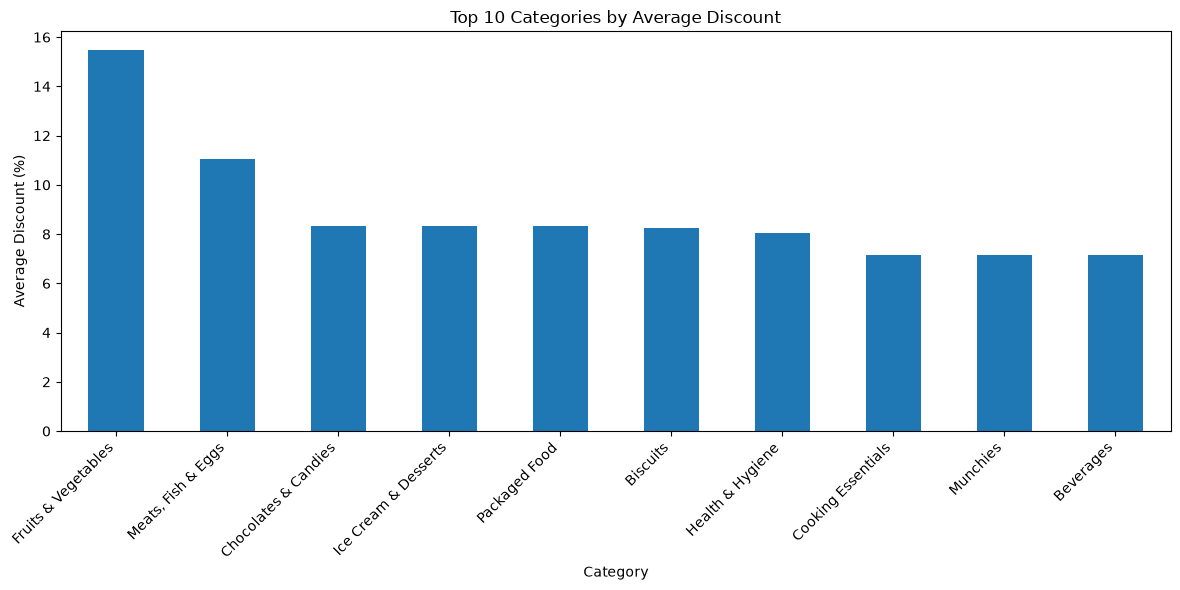

In [14]:
plt.figure(figsize=(12, 6))

category_discount.head(10).plot(kind="bar")

plt.title("Top 10 Categories by Average Discount")
plt.xlabel("Category")
plt.ylabel("Average Discount (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 29. Analyze Product Availability

In this step, we examine how many products are currently available and how many are marked as out of stock.

This helps us understand the overall product availability in the dataset and identify potential inventory availability issues.

In [15]:
stock_counts = df_clean["outOfStock"].value_counts()

stock_counts

outOfStock
False    3277
True      453
Name: count, dtype: int64

## 30. Visualize Product Availability

A bar chart makes it easier to compare the number of available and out-of-stock products.

This visualization provides a quick overview of product availability in the dataset.

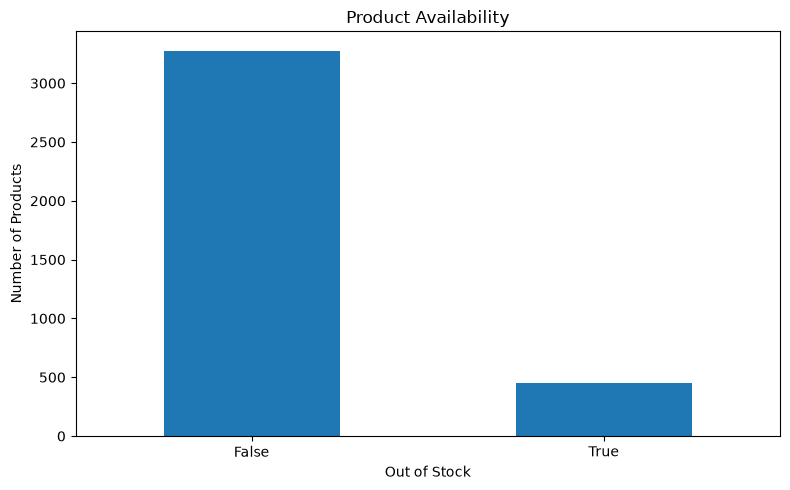

In [16]:
plt.figure(figsize=(8, 5))

stock_counts.plot(kind="bar")

plt.title("Product Availability")
plt.xlabel("Out of Stock")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 31. Calculate Out-of-Stock Percentage

In this step, we calculate the percentage of products that are marked as out of stock.

A percentage is easier to interpret than a raw count and helps us understand the overall availability level of the product catalog.

In [17]:
out_of_stock_percentage = (
    df_clean["outOfStock"].mean() * 100
)

out_of_stock_percentage

np.float64(12.144772117962468)

## 32. Analyze Product Quantity

In this step, we examine the distribution of the `quantity` column.

This helps us understand the typical quantity values in the dataset and identify unusually low or high values.

In [18]:
df_clean["quantity"].describe()

count    3730.000000
mean      213.251206
std       194.781332
min         0.000000
25%        50.000000
50%       181.000000
75%       340.000000
max      1500.000000
Name: quantity, dtype: float64

## 33. Visualize Quantity Distribution

A histogram helps us understand how the quantity values are distributed across the products.

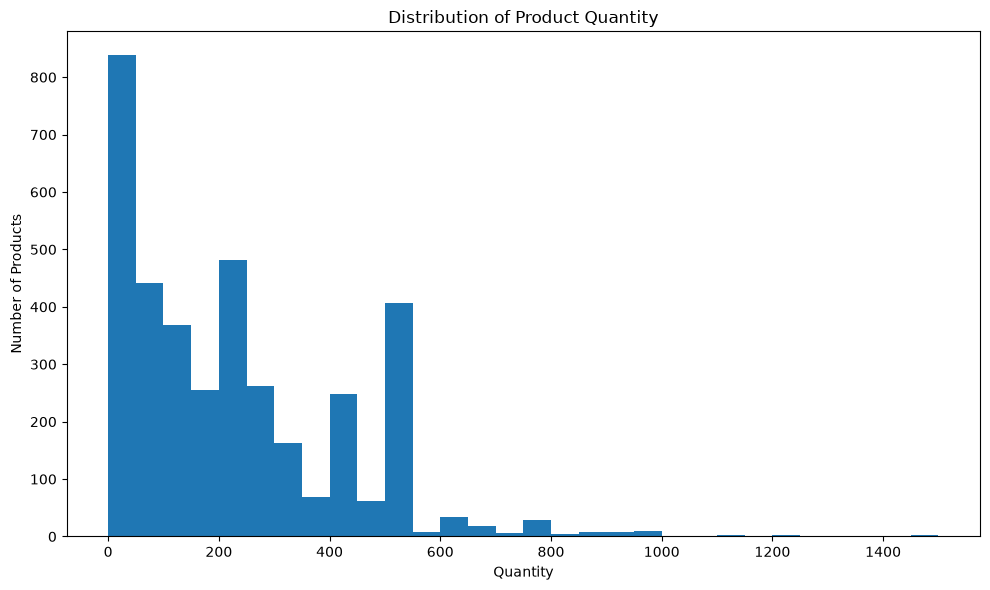

In [19]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["quantity"], bins=30)

plt.title("Distribution of Product Quantity")
plt.xlabel("Quantity")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

## 34. Products With the Highest Quantity

In this step, we identify products with the highest recorded quantity values.

This can help us identify products with unusually large quantity values in the dataset.

In [20]:
df_clean[
    ["name", "Category", "quantity"]
].sort_values(
    "quantity",
    ascending=False
).head(10)

,name,Category,quantity
2817,Savlon Moisture Shield Germ Protection Handwas...,Personal Care,1500
3161,Savlon Moisture Shield Germ Protection Handwas...,Paan Corner,1500
1932,Pedigree Puppy Dry Dog Food Food Chicken & Milk,Ice Cream & Desserts,1200
1544,Pedigree Puppy Dry Dog Food Food Chicken & Milk,Packaged Food,1200
2320,Pedigree Puppy Dry Dog Food Food Chicken & Milk,Chocolates & Candies,1200
1416,Whiskas Kitten (2-12 months) Dry Cat Food Food...,Packaged Food,1100
1804,Whiskas Kitten (2-12 months) Dry Cat Food Food...,Ice Cream & Desserts,1100
2192,Whiskas Kitten (2-12 months) Dry Cat Food Food...,Chocolates & Candies,1100
3554,Shubh kart - Tejas Twisted Cotton Wicks 1000n,Home & Cleaning,1000
3573,Lizol Disinfectant Surface & Floor Cleaner Liq...,Home & Cleaning,975


## 35. Products With the Lowest Quantity

In this step, we identify products with the lowest quantity values.

This helps us understand products associated with very small quantity values.

In [21]:
df_clean[
    ["name", "Category", "quantity"]
].sort_values(
    "quantity",
    ascending=True
).head(10)

,name,Category,quantity
3273,Maybelline New York Colossal Kajal Super Black,Paan Corner,0
2929,Maybelline New York Colossal Kajal Super Black,Personal Care,0
1120,Everest Saffron Kesar,Munchies,0
3184,Maybelline New York Colossal Kajal Black,Paan Corner,0
606,Everest Saffron Kesar,Cooking Essentials,0
2840,Maybelline New York Colossal Kajal Black,Personal Care,0
0,Onion,Fruits & Vegetables,1
646,Popular Essentials Refined Sugar,Munchies,1
647,Fortune Kachi Ghani Mustard Oil Bottle,Munchies,1
653,Gowardhan Cow Ghee Pouch,Munchies,1


## 36. Calculate Customer Savings

In this step, we calculate the absolute savings for each product.

Savings are calculated as the difference between the original MRP and the discounted selling price.

In [22]:
df_clean["savings"] = (
    df_clean["mrp"] -
    df_clean["discountedSellingPrice"]
).round(2)

df_clean[[
    "name",
    "mrp",
    "discountedSellingPrice",
    "savings"
]].head(10)

,name,mrp,discountedSellingPrice,savings
0,Onion,2500,2100,400
1,Tomato Hybrid,4200,3500,700
2,Tender Coconut,5100,4300,800
3,Coriander Leaves,2000,1700,300
4,Ladies Finger,1400,1200,200
5,Potato,3500,2900,600
6,Lemon,7500,6300,1200
7,Watermelon,5800,4900,900
8,Capsicum Green,2300,1900,400
9,Chilli Green,1900,1600,300


## 37. Analyze Customer Savings

We examine the statistical distribution of customer savings to understand the typical and extreme savings values in the dataset.

In [23]:
df_clean["savings"].describe()

count      3730.000000
mean       1487.276139
std        4067.652277
min           0.000000
25%           0.000000
50%         500.000000
75%        1600.000000
max      120100.000000
Name: savings, dtype: float64

## 38. Products With the Highest Savings

In this step, we identify products that have the largest difference between MRP and discounted selling price.

In [24]:
df_clean[
    [
        "name",
        "Category",
        "mrp",
        "discountedSellingPrice",
        "discountPercent",
        "savings"
    ]
].sort_values(
    "savings",
    ascending=False
).head(10)

,name,Category,mrp,discountedSellingPrice,discountPercent,savings
517,Borges Extra Light Olive Oil Bottle,Cooking Essentials,260000,139900,46,120100
1031,Borges Extra Light Olive Oil Bottle,Munchies,260000,139900,46,120100
3016,Pampers Pants - Large,Personal Care,154900,84900,45,70000
3360,Pampers Pants - Large,Paan Corner,154900,84900,45,70000
1935,Kelloggs Chocos - Moons & Stars,Ice Cream & Desserts,66000,39600,40,26400
2323,Kelloggs Chocos - Moons & Stars,Chocolates & Candies,66000,39600,40,26400
1547,Kelloggs Chocos - Moons & Stars,Packaged Food,66000,39600,40,26400
3367,Pampers Active Baby Diapers New Born Extra Small,Paan Corner,109900,84900,22,25000
3023,Pampers Active Baby Diapers New Born Extra Small,Personal Care,109900,84900,22,25000
768,Popular Essentials Californian Almond,Munchies,69500,47000,32,22500


## 39. Compare MRP and Discounted Selling Price

This scatter plot compares the original MRP with the discounted selling price.

The relationship between these two variables helps us understand how selling prices change as product prices increase.

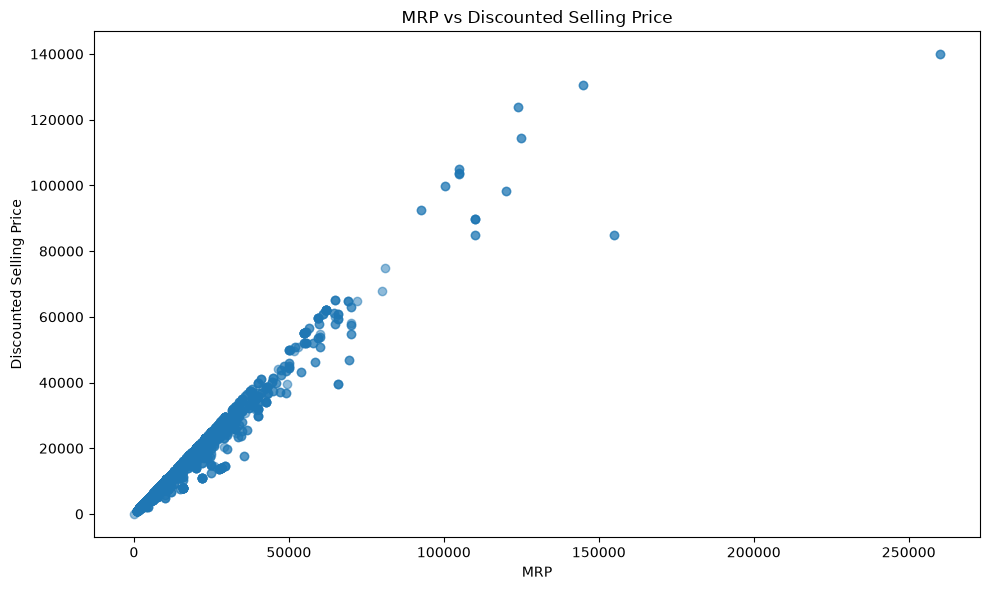

In [25]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["mrp"],
    df_clean["discountedSellingPrice"],
    alpha=0.5
)

plt.title("MRP vs Discounted Selling Price")
plt.xlabel("MRP")
plt.ylabel("Discounted Selling Price")

plt.tight_layout()
plt.show()

## 40. Average MRP by Product Category

In this step, we calculate the average MRP for each product category.

This allows us to compare the typical product price across categories.

In [26]:
category_mrp = (
    df_clean.groupby("Category")["mrp"]
    .mean()
    .sort_values(ascending=False)
)

category_mrp.head(10)

Category
Paan Corner             20728.571429
Personal Care           20728.571429
Meats, Fish & Eggs      18728.571429
Health & Hygiene        15917.525773
Cooking Essentials      15653.501946
Munchies                15653.501946
Chocolates & Candies    15572.680412
Ice Cream & Desserts    15572.680412
Packaged Food           15572.680412
Home & Cleaning         15215.463918
Name: mrp, dtype: float64

## 41. Visualize Average MRP by Category

A bar chart helps us compare the categories with the highest average MRP.

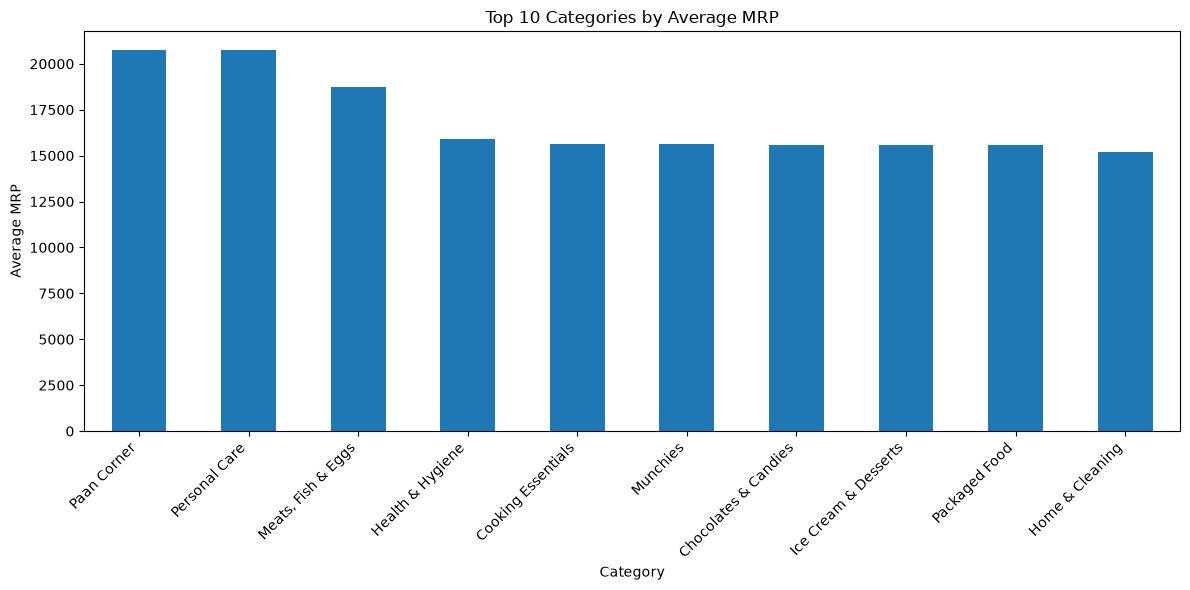

In [27]:
plt.figure(figsize=(12, 6))

category_mrp.head(10).plot(kind="bar")

plt.title("Top 10 Categories by Average MRP")
plt.xlabel("Category")
plt.ylabel("Average MRP")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 42. Average Selling Price by Category

In this step, we calculate the average discounted selling price for each category.

This helps us compare the typical selling price across different product categories.

In [28]:
category_selling_price = (
    df_clean.groupby("Category")["discountedSellingPrice"]
    .mean()
    .sort_values(ascending=False)
)

category_selling_price.head(10)

Category
Paan Corner             18989.795918
Personal Care           18989.795918
Meats, Fish & Eggs      16409.523810
Health & Hygiene        14585.567010
Home & Cleaning         14144.845361
Chocolates & Candies    14107.731959
Ice Cream & Desserts    14107.731959
Packaged Food           14107.731959
Cooking Essentials      14082.684825
Munchies                14082.684825
Name: discountedSellingPrice, dtype: float64

## 43. Analyze Out-of-Stock Products by Category

In this step, we calculate the number of out-of-stock products in each category.

This can help identify categories containing larger numbers of unavailable products.

In [29]:
category_stock = (
    df_clean.groupby("Category")["outOfStock"]
    .sum()
    .sort_values(ascending=False)
)

category_stock.head(10)

Category
Cooking Essentials       64
Munchies                 64
Chocolates & Candies     45
Ice Cream & Desserts     45
Packaged Food            45
Biscuits                 42
Beverages                28
Dairy, Bread & Batter    28
Paan Corner              21
Personal Care            21
Name: outOfStock, dtype: int64

## 44. Most Expensive Products

In this step, we identify the products with the highest MRP values.

This helps us understand the upper end of the product price range.

In [30]:
df_clean[
    ["name", "Category", "mrp", "discountPercent"]
].sort_values(
    "mrp",
    ascending=False
).head(10)

,name,Category,mrp,discountPercent
517,Borges Extra Light Olive Oil Bottle,Cooking Essentials,260000,46
1031,Borges Extra Light Olive Oil Bottle,Munchies,260000,46
3016,Pampers Pants - Large,Personal Care,154900,45
3360,Pampers Pants - Large,Paan Corner,154900,45
877,Praakritik Natural Desi Gir Cow A2 Ghee,Munchies,145000,10
363,Praakritik Natural Desi Gir Cow A2 Ghee,Cooking Essentials,145000,10
121,Dhara Kachi Ghani Mustard Oil Jar,Cooking Essentials,125000,8
635,Dhara Kachi Ghani Mustard Oil Jar,Munchies,125000,8
658,Saffola Gold (Jar),Munchies,124000,0
144,Saffola Gold (Jar),Cooking Essentials,124000,0


## 45. Products With the Highest Discount Percentage

In this step, we identify products with the highest recorded discount percentages.

This helps us understand which products have the largest percentage reductions from MRP.

In [31]:
df_clean[
    [
        "name",
        "Category",
        "mrp",
        "discountPercent",
        "discountedSellingPrice"
    ]
].sort_values(
    "discountPercent",
    ascending=False
).head(10)

,name,Category,mrp,discountPercent,discountedSellingPrice
2619,Dukes Waffy Strawberry Wafers,Biscuits,4500,51,2200
2608,Dukes Waffy Chocolate Wafers,Biscuits,4500,51,2200
2615,Dukes Waffy Orange Wafers,Biscuits,4500,51,2200
1191,RRO Cheddar Block Cheese,"Dairy, Bread & Batter",29500,50,14700
1195,RRO Fresh Ricotta,"Dairy, Bread & Batter",27500,50,13700
1197,RRO Mozzarella Pizza Cheese,"Dairy, Bread & Batter",27500,50,13700
1643,Moi Soi Black Bean Sauce - Dip Spread Stir Fr...,Packaged Food,28000,50,14000
1200,RRO Burrata Cheese,"Dairy, Bread & Batter",25000,50,12500
1326,RRO Mozzarella Pizza Cheese,Beverages,27500,50,13700
1213,RRO Mascarpone Cheese,"Dairy, Bread & Batter",35500,50,17700


## 46. Lowest-Priced Products

In this step, we identify products with the lowest non-zero MRP values.

This helps us understand the lower end of the product price range.

In [32]:
df_clean[
    ["name", "Category", "mrp", "discountedSellingPrice"]
].sort_values(
    "mrp",
    ascending=True
).head(10)

,name,Category,mrp,discountedSellingPrice
3606,Cherry Blossom Liquid Shoe Polish Neutral,Home & Cleaning,0,0
2206,Ching's Secret Tomato Instant Soup,Chocolates & Candies,1000,1000
1887,Ching's Secret Mix Veg Instant Soup,Ice Cream & Desserts,1000,1000
2120,Ching's Chow Mein Hakka Noodles Masala,Ice Cream & Desserts,1000,1000
2176,Ching's Secret Manchow Instant Soup,Chocolates & Candies,1000,1000
2183,Chings Instant Soup - Hot & Sour,Chocolates & Candies,1000,1000
2193,Chings Instant Soup - Sweet Corn Veg,Chocolates & Candies,1000,1000
2275,Ching's Secret Mix Veg Instant Soup,Chocolates & Candies,1000,1000
2508,Ching's Chow Mein Hakka Noodles Masala,Chocolates & Candies,1000,1000
2562,Ching's Chicken Chilli Masala,"Meats, Fish & Eggs",1000,1000


## 47. Analyze Product Weight

The dataset contains product weight information in grams.

We examine its statistical distribution to understand the typical product weight and identify extreme values.

In [33]:
df_clean["weightInGms"].describe()

count     3730.000000
mean       387.917694
std        678.270812
min          0.000000
25%        100.000000
50%        225.000000
75%        450.000000
max      10000.000000
Name: weightInGms, dtype: float64

## 48. Analyze Available Quantity

In this step, we examine the `availableQuantity` column.

This provides an overview of the recorded availability quantity for products in the dataset.

In [34]:
df_clean["availableQuantity"].describe()

count    3730.000000
mean        4.007507
std         2.203619
min         0.000000
25%         2.000000
50%         5.000000
75%         6.000000
max         6.000000
Name: availableQuantity, dtype: float64

## 49. Average Available Quantity by Category

In this step, we calculate the average available quantity for each product category.

This allows us to compare recorded availability levels across categories.

In [35]:
category_quantity = (
    df_clean.groupby("Category")["availableQuantity"]
    .mean()
    .sort_values(ascending=False)
)

category_quantity.head(10)

Category
Health & Hygiene        4.381443
Home & Cleaning         4.324742
Cooking Essentials      4.252918
Munchies                4.252918
Paan Corner             4.233236
Personal Care           4.233236
Chocolates & Candies    3.920103
Ice Cream & Desserts    3.920103
Packaged Food           3.920103
Beverages               3.759690
Name: availableQuantity, dtype: float64

## 50. Out-of-Stock Rate by Category

In this step, we calculate the percentage of products marked as out of stock within each category.

Using a percentage allows us to compare categories of different sizes more fairly.

In [36]:
category_out_of_stock_rate = (
    df_clean.groupby("Category")["outOfStock"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

category_out_of_stock_rate.head(10)

Category
Biscuits                 28.571429
Beverages                21.705426
Dairy, Bread & Batter    21.705426
Meats, Fish & Eggs       19.047619
Health & Hygiene         13.402062
Cooking Essentials       12.451362
Munchies                 12.451362
Chocolates & Candies     11.597938
Ice Cream & Desserts     11.597938
Packaged Food            11.597938
Name: outOfStock, dtype: float64

## 51. Create Category Performance Summary

In this step, we combine multiple category-level metrics into a single summary table.

This creates a more useful analytical view than examining individual calculations separately.

In [37]:
category_summary = (
    df_clean.groupby("Category")
    .agg(
        product_count=("name", "count"),
        average_mrp=("mrp", "mean"),
        average_selling_price=("discountedSellingPrice", "mean"),
        average_discount=("discountPercent", "mean"),
        average_quantity=("quantity", "mean"),
        out_of_stock_rate=("outOfStock", "mean")
    )
)

category_summary["out_of_stock_rate"] = (
    category_summary["out_of_stock_rate"] * 100
).round(2)

category_summary = category_summary.sort_values(
    "product_count",
    ascending=False
)

category_summary.head(10)

,product_count,average_mrp,average_selling_price,average_discount,average_quantity,out_of_stock_rate
Category,,,,,,
Cooking Essentials,514,15653.501946,14082.684825,7.163424,207.177043,12.45
Munchies,514,15653.501946,14082.684825,7.163424,207.177043,12.45
Chocolates & Candies,388,15572.680412,14107.731959,8.324742,266.726804,11.60
Ice Cream & Desserts,388,15572.680412,14107.731959,8.324742,266.726804,11.60
Packaged Food,388,15572.680412,14107.731959,8.324742,266.726804,11.60
Paan Corner,343,20728.571429,18989.795918,6.239067,176.180758,6.12
Personal Care,343,20728.571429,18989.795918,6.239067,176.180758,6.12
Home & Cleaning,194,15215.463918,14144.845361,5.675258,134.582474,9.79
Biscuits,147,5948.979592,5277.959184,8.244898,176.931973,28.57


## 52. Analyze Categories by Product Count

In this step, we identify categories containing the largest number of products.

Categories with more products represent a larger portion of the product catalog in this dataset.

In [38]:
category_summary.sort_values(
    "product_count",
    ascending=False
).head(10)

,product_count,average_mrp,average_selling_price,average_discount,average_quantity,out_of_stock_rate
Category,,,,,,
Cooking Essentials,514,15653.501946,14082.684825,7.163424,207.177043,12.45
Munchies,514,15653.501946,14082.684825,7.163424,207.177043,12.45
Chocolates & Candies,388,15572.680412,14107.731959,8.324742,266.726804,11.60
Ice Cream & Desserts,388,15572.680412,14107.731959,8.324742,266.726804,11.60
Packaged Food,388,15572.680412,14107.731959,8.324742,266.726804,11.60
Paan Corner,343,20728.571429,18989.795918,6.239067,176.180758,6.12
Personal Care,343,20728.571429,18989.795918,6.239067,176.180758,6.12
Home & Cleaning,194,15215.463918,14144.845361,5.675258,134.582474,9.79
Biscuits,147,5948.979592,5277.959184,8.244898,176.931973,28.57


## 53. Analyze Categories by Average Discount

In this step, we examine categories with the highest average discount percentages.

This helps us understand where larger discounts are more commonly observed in the dataset.

In [39]:
category_summary.sort_values(
    "average_discount",
    ascending=False
).head(10)

,product_count,average_mrp,average_selling_price,average_discount,average_quantity,out_of_stock_rate
Category,,,,,,
Fruits & Vegetables,93,4701.075269,3983.870968,15.462366,172.365591,6.45
"Meats, Fish & Eggs",63,18728.571429,16409.523810,11.031746,273.507937,19.05
Chocolates & Candies,388,15572.680412,14107.731959,8.324742,266.726804,11.60
Ice Cream & Desserts,388,15572.680412,14107.731959,8.324742,266.726804,11.60
Packaged Food,388,15572.680412,14107.731959,8.324742,266.726804,11.60
Biscuits,147,5948.979592,5277.959184,8.244898,176.931973,28.57
Health & Hygiene,97,15917.525773,14585.567010,8.051546,83.030928,13.40
Cooking Essentials,514,15653.501946,14082.684825,7.163424,207.177043,12.45
Munchies,514,15653.501946,14082.684825,7.163424,207.177043,12.45


## 54. Create the Final Analysis Dataset

After completing the data cleaning and exploratory analysis, we create a final analysis-ready dataset.

Additional calculated variables such as customer savings are included for further analysis and reporting.

In [40]:
analysis_df = df_clean[
    [
        "Category",
        "name",
        "mrp",
        "discountPercent",
        "availableQuantity",
        "discountedSellingPrice",
        "weightInGms",
        "outOfStock",
        "quantity",
        "savings"
    ]
].copy()

analysis_df.head()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity,savings
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1,400
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1,700
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1,800
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100,300
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250,200


In [41]:
analysis_df.shape

(3730, 10)

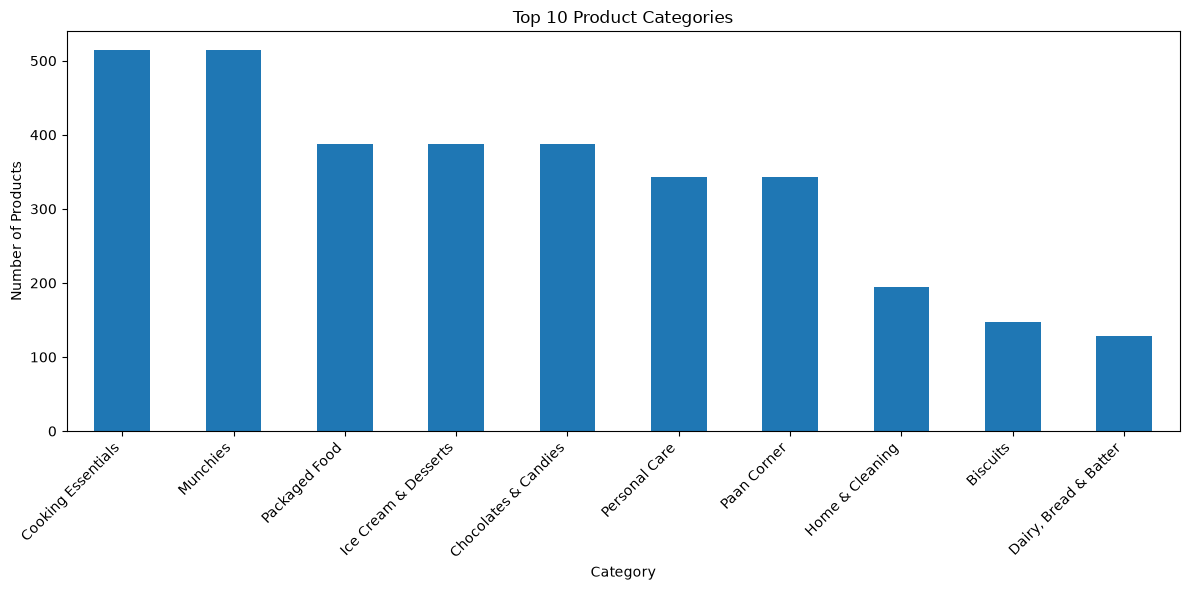

In [42]:
plt.figure(figsize=(12, 6))

df_clean["Category"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

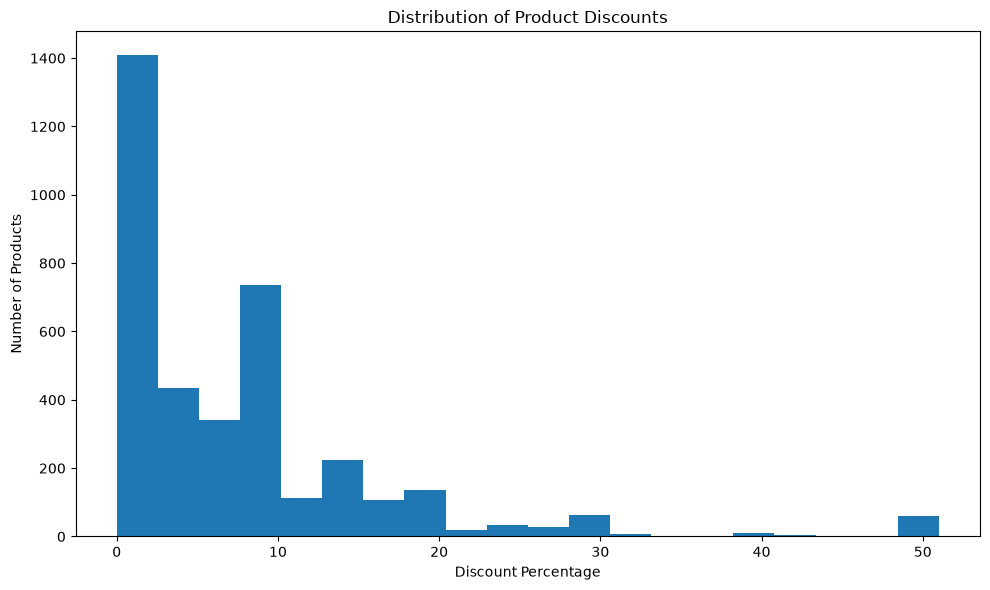

In [43]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["discountPercent"], bins=20)

plt.title("Distribution of Product Discounts")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

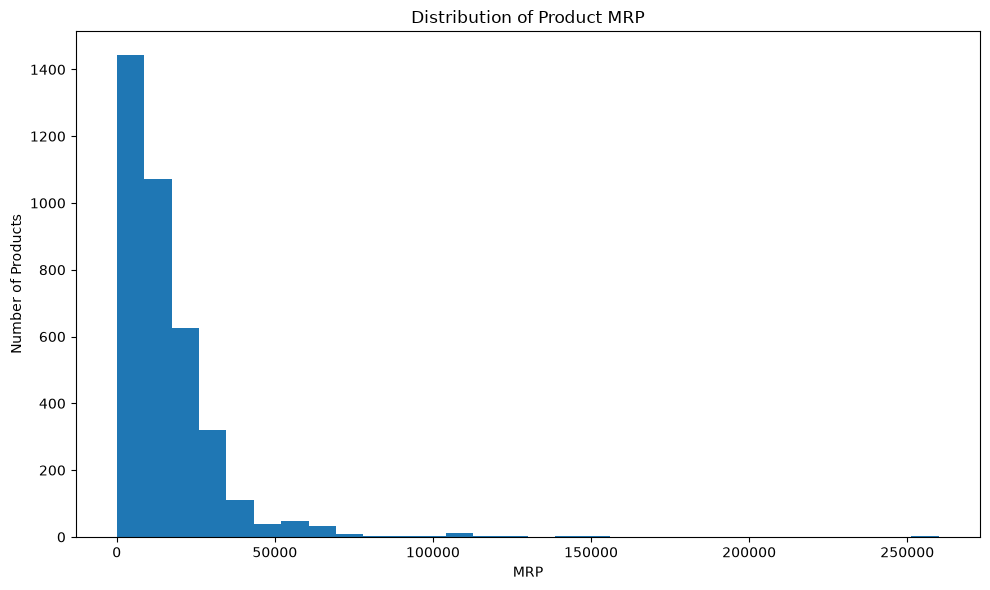

In [44]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["mrp"], bins=30)

plt.title("Distribution of Product MRP")
plt.xlabel("MRP")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

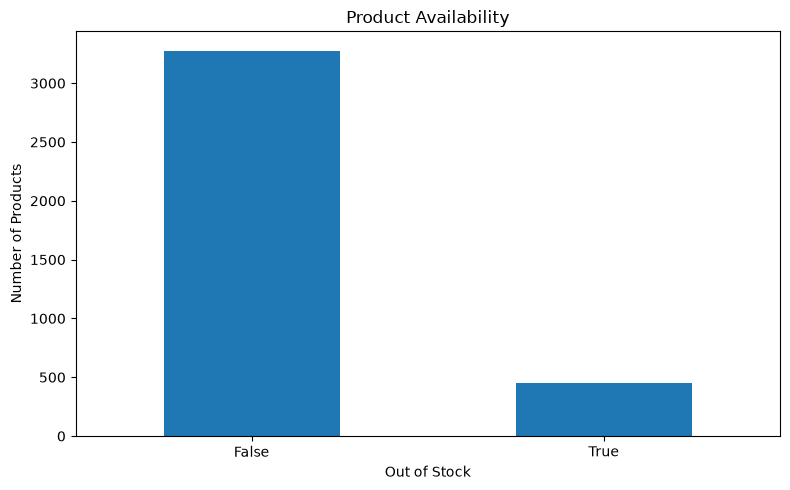

In [45]:
plt.figure(figsize=(8, 5))

stock_counts.plot(kind="bar")

plt.title("Product Availability")
plt.xlabel("Out of Stock")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 56. Project Conclusions

## Key Findings

This project analyzed a Zepto-style product catalog dataset to understand product categories, pricing, discounts, product availability, quantity, and inventory-related patterns.

### Data Quality

- Duplicate records were identified and removed.
- One product record contained an MRP of zero and was excluded from the analysis dataset.
- Pricing calculations were validated by comparing calculated selling prices with recorded discounted selling prices.
- Small pricing differences were observed, which may be associated with rounding or pricing rules.

### Product Catalog

- The dataset contains products from multiple categories.
- Some categories contain substantially more products than others.
- Category-level analysis was used to compare product counts, pricing, discounts, and availability.

### Pricing

- MRP and discounted selling prices were analyzed.
- Customer savings were calculated as the difference between MRP and discounted selling price.
- Products with particularly high savings and discount percentages were identified.

### Product Availability

- Product availability was analyzed using the `outOfStock` field.
- Both overall and category-level out-of-stock rates were calculated.

### Important Limitation

The dataset represents product-level catalog information. The `quantity` field has not been assumed to represent sales volume because the dataset does not provide sufficient business context to confirm that interpretation.

## Conclusion

The analysis demonstrates how Python and Pandas can be used to clean, validate, explore, and analyze an e-commerce product dataset.

The project also demonstrates the process of transforming raw data into meaningful analytical metrics and visualizations that can support further business analysis.

## 57. Export the Final Analysis Dataset

The cleaned analysis dataset is exported as a CSV file so that it can be reused in future analysis, visualization tools, or machine learning workflows.

In [46]:
analysis_df.to_csv(
    "../outputs/zepto_analysis_clean.csv",
    index=False
)

In [47]:
import os

os.path.exists("../outputs/zepto_analysis_clean.csv")

True